In [625]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import statsmodels.api as sm
import scipy.stats as stats
from matplotlib.ticker import FuncFormatter
from statsmodels.formula.api import ols


In [626]:

#Loading data from movie.csv
movies = pd.read_csv('DATA/movies.csv')
movies = movies[movies['year'] != 2019].copy()
movies['total_gross'] = movies['domestic_gross'] + movies['foreign_gross']
movies.head()



,movie,year,genres,runtime_minutes,averagerating,numvotes,studio,domestic_gross,foreign_gross,total_gross
0,Wazir,2016,"Action,Crime,Drama",103.0,7.1,15378,Relbig.,1100000.0,0.0,1100000.0
1,On the Road,2012,"Adventure,Drama,Romance",124.0,6.1,37886,IFC,744000.0,8000000.0,8744000.0
2,The Secret Life of Walter Mitty,2013,"Adventure,Comedy,Drama",114.0,7.3,275300,Fox,58200000.0,129900000.0,188100000.0
3,A Walk Among the Tombstones,2014,"Action,Crime,Drama",114.0,6.5,105116,Uni.,26300000.0,26900000.0,53200000.0
4,Jurassic World,2015,"Action,Adventure,Sci-Fi",124.0,7.0,539338,Uni.,652300000.0,1019.4,652301019.4


## how is the competition and what niches can we exploit for a start (studio)

### Studios vs Genres

In [627]:
sg = (
    movies.assign(genres=movies['genres'].str.split(','))
          .explode('genres')
          .assign(genres=lambda df: df['genres'].str.strip())
)
sg


,movie,year,genres,runtime_minutes,averagerating,numvotes,studio,domestic_gross,foreign_gross,total_gross
0,Wazir,2016,Action,103.0,7.1,15378,Relbig.,1100000.0,0.0,1100000.0
0,Wazir,2016,Crime,103.0,7.1,15378,Relbig.,1100000.0,0.0,1100000.0
0,Wazir,2016,Drama,103.0,7.1,15378,Relbig.,1100000.0,0.0,1100000.0
1,On the Road,2012,Adventure,124.0,6.1,37886,IFC,744000.0,8000000.0,8744000.0
1,On the Road,2012,Drama,124.0,6.1,37886,IFC,744000.0,8000000.0,8744000.0
...,...,...,...,...,...,...,...,...,...,...
3050,Eden,2018,Drama,97.0,6.7,20,BG,65500.0,0.0,65500.0
3051,Unstoppable,2018,Action,116.0,6.5,576,Fox,81600000.0,86200000.0,167800000.0
3051,Unstoppable,2018,Crime,116.0,6.5,576,Fox,81600000.0,86200000.0,167800000.0
3052,Neighbors,2018,Comedy,90.0,7.6,18,Uni.,150200000.0,120500000.0,270700000.0


In [628]:

#Filter to top 10 studios & genres
top_studios = sg['studio'].value_counts().nlargest(10).index
top_genres = sg['genres'].value_counts().nlargest(10).index
studio_genre_df = sg[sg['studio'].isin(top_studios) & 
                       sg['genres'].isin(top_genres)]
studio_genre_df #top studios, top genres


,movie,year,genres,runtime_minutes,averagerating,numvotes,studio,domestic_gross,foreign_gross,total_gross
1,On the Road,2012,Adventure,124.0,6.1,37886,IFC,744000.0,8000000.0,8744000.0
1,On the Road,2012,Drama,124.0,6.1,37886,IFC,744000.0,8000000.0,8744000.0
1,On the Road,2012,Romance,124.0,6.1,37886,IFC,744000.0,8000000.0,8744000.0
2,The Secret Life of Walter Mitty,2013,Adventure,114.0,7.3,275300,Fox,58200000.0,129900000.0,188100000.0
2,The Secret Life of Walter Mitty,2013,Comedy,114.0,7.3,275300,Fox,58200000.0,129900000.0,188100000.0
...,...,...,...,...,...,...,...,...,...,...
3045,Joy,2018,Drama,99.0,6.5,430,Fox,56500000.0,44700000.0,101200000.0
3051,Unstoppable,2018,Action,116.0,6.5,576,Fox,81600000.0,86200000.0,167800000.0
3051,Unstoppable,2018,Crime,116.0,6.5,576,Fox,81600000.0,86200000.0,167800000.0
3052,Neighbors,2018,Comedy,90.0,7.6,18,Uni.,150200000.0,120500000.0,270700000.0


##### Chi-square test to conclude whether or not there is a relationship between Studios and Genres


 - Create contingency table
 - Conduct **chi-square test of independence** to assess relationship between studios and genres by comparing observed counts to counts expected, initially assuming they were **independent**
 

In [629]:
cross_tabulation = pd.crosstab(studio_genre_df['studio'], studio_genre_df['genres'])
chi_square, p_value, _, expected = stats.chi2_contingency(cross_tabulation)
print(f'chi-square = {chi_square:.2f}\np-value = {p_value:.10f}')
cross_tabulation

chi-square = 539.14
p-value = 0.0000000000


genres,Action,Adventure,Biography,Comedy,Crime,Documentary,Drama,Horror,Romance,Thriller
studio,,,,,,,,,,
BV,30,58,9,38,3,7,24,1,5,3
Fox,47,53,8,56,16,3,50,12,10,15
IFC,5,5,11,38,22,16,114,15,32,20
LGF,31,16,6,38,16,1,39,13,13,23
Magn.,26,9,11,26,14,19,72,17,13,26
Par.,25,28,6,32,5,7,37,13,8,17
SPC,2,2,26,29,6,14,87,3,35,14
Sony,38,30,7,48,17,1,31,2,10,20
Uni.,53,33,12,63,18,3,56,23,25,35


**Observations**
 - **H0 (*Null Hypothesis*)**: Studios and genres are independent. (No association)
 - The **p-value** is **0.0000**: Staggeringly low p-value. Strongly indicating extreme evidence against the null hypothesis of independence.

**Decision**
 - Assuming an alpha level of 0.05, we **reject the null hypothesis**.
 - In turn concluding that there _is_ a statistically significant association between studios and genres.
 

**Visualization** 
 - Visualizing the existing relationship between studios and genres using a stacked bar chart showing proportionally which genres are favoured by the top 8 studios.

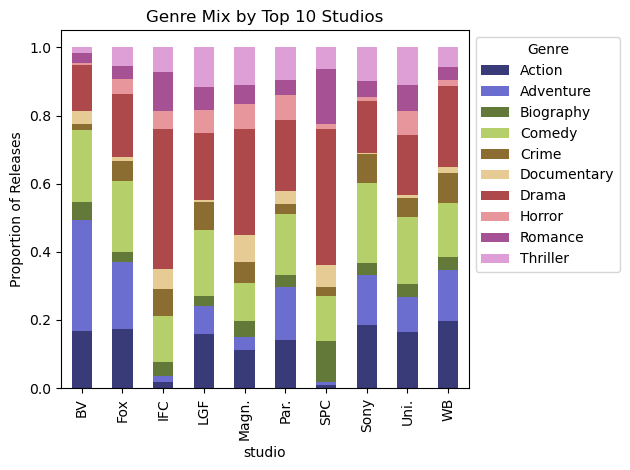

In [630]:
genre_studio_mix = cross_tabulation.div(cross_tabulation.sum(axis=1), axis=0)
genre_studio_mix.plot(kind='bar', stacked=True,  cmap='tab20b')
plt.legend(title='Genre', bbox_to_anchor=(1,1))
plt.title('Genre Mix by Top 10 Studios')
plt.ylabel('Proportion of Releases')
plt.tight_layout()
plt.show()

##### Calculating Standardized Residuals to determine how strongly the two variables are related

 - Calculate **std_residuals** by dividing the difference between observed and expected counts by the square root of the expected counts.
 - Visualize std_residuals (a dataframe) by plotting a heatmap that shows the strength of the relationship between each studios and genres.

In [631]:
std_residuals = (cross_tabulation - expected) / np.sqrt(expected)
std_residuals

genres,Action,Adventure,Biography,Comedy,Crime,Documentary,Drama,Horror,Romance,Thriller
studio,,,,,,,,,,
BV,1.337285,8.166804,0.328606,1.217124,-2.344967,0.505767,-2.960077,-2.457813,-2.071880,-2.989320
Fox,1.897225,3.827527,-1.210977,1.260563,-0.039988,-1.949066,-1.972516,-0.001481,-1.991378,-1.438572
IFC,-5.235138,-4.818473,-0.450365,-1.537127,1.314095,2.318124,5.580817,0.750658,2.940842,-0.495999
LGF,1.003607,-1.437704,-0.967147,0.621593,1.246228,-2.127335,-1.290084,1.451570,-0.133741,1.825669
Magn.,-0.861759,-3.489047,0.135648,-2.322441,0.014425,4.153822,1.989811,2.062955,-0.758611,1.680476
Par.,0.306197,1.584999,-0.727660,0.142975,-1.732234,0.505767,-0.989695,1.807685,-1.214816,0.711980
SPC,-4.993834,-4.647732,5.128781,-1.490362,-1.951228,2.598811,4.613901,-2.149775,5.161587,-0.841394
Sony,2.128550,1.268519,-0.738344,2.047055,1.370693,-2.186170,-2.674162,-2.347665,-1.078630,0.889847
Uni.,1.626745,-0.729627,-0.667852,0.897508,-0.276809,-2.300649,-2.539518,2.310056,0.617938,1.811070


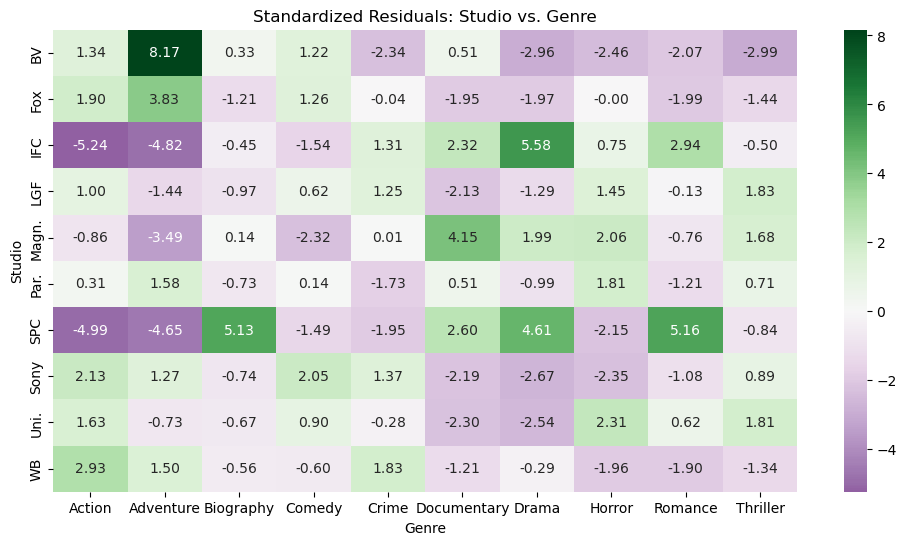

In [632]:
plt.figure(figsize=(12, 6))
sns.heatmap(std_residuals, annot=True, center=0, fmt=".2f", cmap="PRGn")
plt.title('Standardized Residuals: Studio vs. Genre')
plt.xlabel('Genre')
plt.ylabel('Studio')
plt.show()

In [633]:
underserved = std_residuals.stack().loc[lambda x: x <= -2]
print("\nUnder-represented genre–studio combos (std_resid ≤ -2):")
print(underserved)



Under-represented genre–studio combos (std_resid ≤ -2):
studio  genres     
BV      Crime         -2.344967
        Drama         -2.960077
        Horror        -2.457813
        Romance       -2.071880
        Thriller      -2.989320
IFC     Action        -5.235138
        Adventure     -4.818473
LGF     Documentary   -2.127335
Magn.   Adventure     -3.489047
        Comedy        -2.322441
SPC     Action        -4.993834
        Adventure     -4.647732
        Horror        -2.149775
Sony    Documentary   -2.186170
        Drama         -2.674162
        Horror        -2.347665
Uni.    Documentary   -2.300649
        Drama         -2.539518
dtype: float64


 - Big Studios neglect Drama/Romance - a new studio can build an audience with emotionally driven, mid-budget Drama/Romance films. 

 - Independent studios neglect Action and Adventure genres and can be promising avenue 

### Studios vs. Average Rating

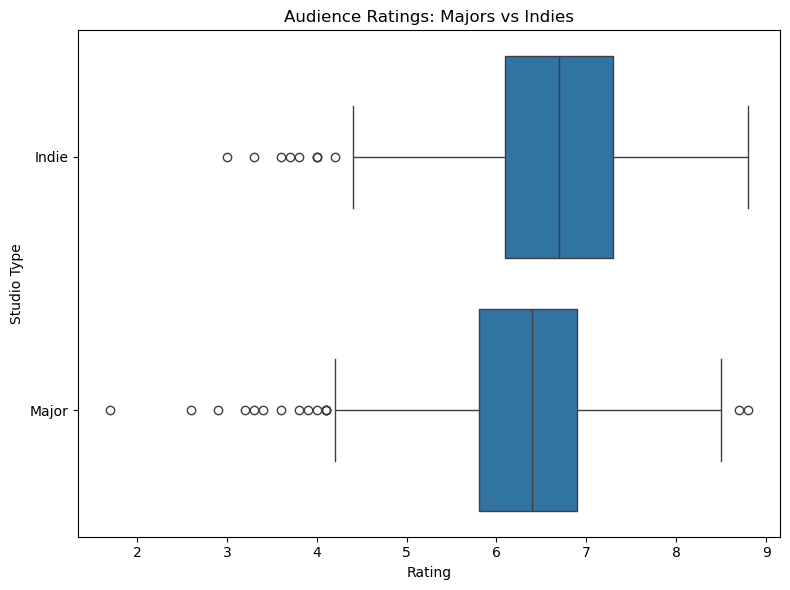

In [634]:
majors = ['Uni.', 'Fox', 'WB', 'Sony', 'Disney']
indie_counts = movies.loc[~movies['studio'].isin(majors), 'studio'].value_counts()
indies = indie_counts.nlargest(5).index.tolist()

indies_majors = movies[movies['studio'].isin(majors + indies)].copy()

plt.figure(figsize=(8,6))
sns.boxplot(x='averagerating', y=indies_majors['studio'].apply(lambda s: 'Major' if s in majors else 'Indie'),
            data=indies_majors)
plt.title('Audience Ratings: Majors vs Indies')
plt.xlabel('Rating')
plt.ylabel('Studio Type')
plt.tight_layout()
plt.show()


In [635]:

majors_r = indies_majors[indies_majors['studio'].isin(majors)]['averagerating']
indies_r = indies_majors[indies_majors['studio'].isin(indies)]['averagerating']
t_statistic, p_value = stats.ttest_ind(majors_r, indies_r, equal_var=False)
print(f"Majors mean={majors_r.mean():.2f}\nIndies mean={indies_r.mean():.2f}\nt={t_statistic:.2f}\np={p_value:.4f}")


Majors mean=6.33
Indies mean=6.63
t=-5.19
p=0.0000


 - Statistically significant that **Indies** perform better than **Major** studios in terms of audience rating.
 
 - Position ourselves as a indie studio, ship fewer projects, hire great actors and quality scripts that reasonate with our audience.

In [636]:
volume = indies_majors['studio'].value_counts()
means  = indies_majors.groupby('studio')['averagerating'].mean()
correlation_coefficient, p_value = stats.pearsonr(volume.loc[means.index], means)
print(f"Volume vs. Mean Rating: r={correlation_coefficient:.2f}, p_value={p_value:.4f}")

Volume vs. Mean Rating: r=-0.20, p_value=0.6108


 - No significant correlation between number of films you make and mean rating. Its more about quality than quantity. 
 - Focus on quality and genre fit over just releasing alot of films.
 

In [637]:

print("Studios with significantly below industry ratings:")
industry_mean = indies_majors['averagerating'].mean()
for studio, grp in indies_majors.groupby('studio'):
    if grp['averagerating'].mean() < industry_mean:
        other = indies_majors[indies_majors['studio']!=studio]['averagerating']
        t, p = stats.ttest_ind(grp['averagerating'], other, equal_var=False)
        if p < 0.05:
            print(f" • {studio}: {grp['averagerating'].mean():.2f} vs {other.mean():.2f}, p={p:.4f}")




Studios with significantly below industry ratings:
 • Fox: 6.32 vs 6.52, p=0.0417
 • LGF: 6.25 vs 6.51, p=0.0163
 • Sony: 6.22 vs 6.52, p=0.0060
 • Uni.: 6.22 vs 6.54, p=0.0001


 - Position ourselves as a indie studio, ship fewer projects, hire great actors and quality scripts that reasonate with our audience.
 
 - Avoid direct competition in major studios' focus genres where they dominate but disappoint audiences. Shows that its not easy to please the audience in these genres.
 
 - From previous analysis, target genres both types of studios neglect but audiences appreciate quality
 

### Studio vs Total Gross vs Year

In [638]:
studio_year = (
    movies
    .groupby(['year', 'studio'])['total_gross']
    .sum()
    .reset_index()
)

top_studios = (
    movies
    .groupby('studio')['total_gross']
    .sum()
    .nlargest(20)
    .index
    .tolist()
)


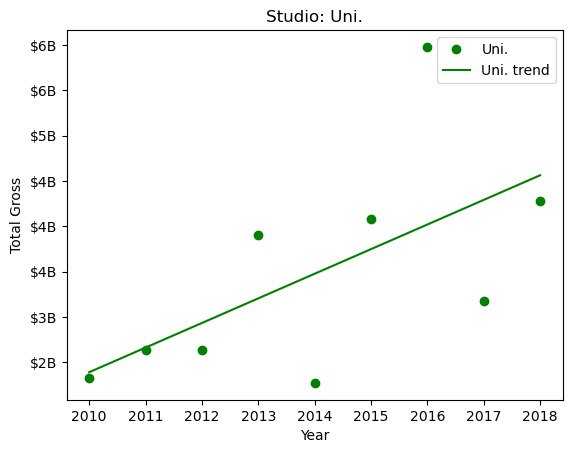


Studio: Uni.
 -> Slope (gross per year) = 271404836.91
 -> r2 (trend confidence) = 0.3769
 -> p-value (year coefficient) = 0.0786
 -> Trend = upward
 -> Significance = (not significant)



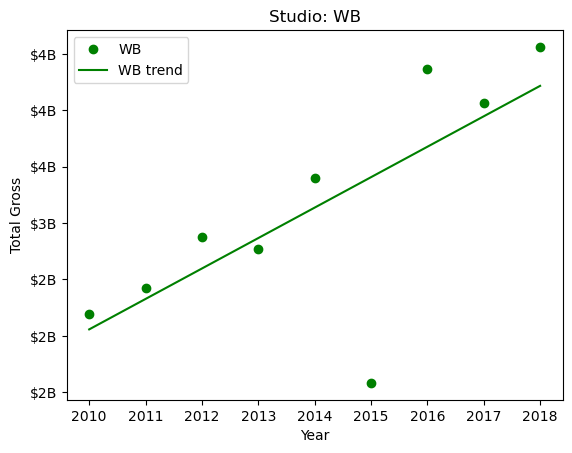


Studio: WB
 -> Slope (gross per year) = 270030766.73
 -> r2 (trend confidence) = 0.5146
 -> p-value (year coefficient) = 0.0296
 -> Trend = upward
 -> Significance = (significant)



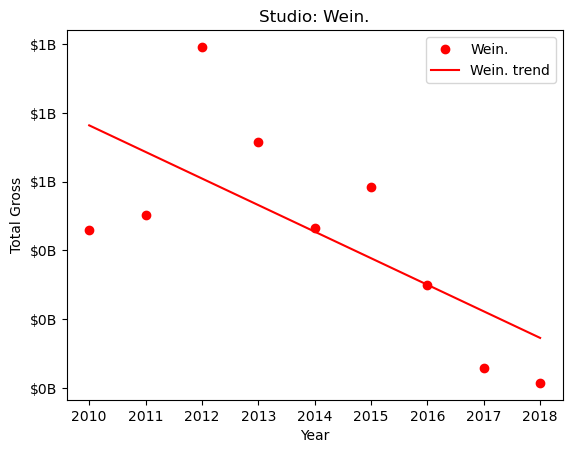


Studio: Wein.
 -> Slope (gross per year) = -77215791.65
 -> r2 (trend confidence) = 0.4767
 -> p-value (year coefficient) = 0.0395
 -> Trend = downward
 -> Significance = (significant)



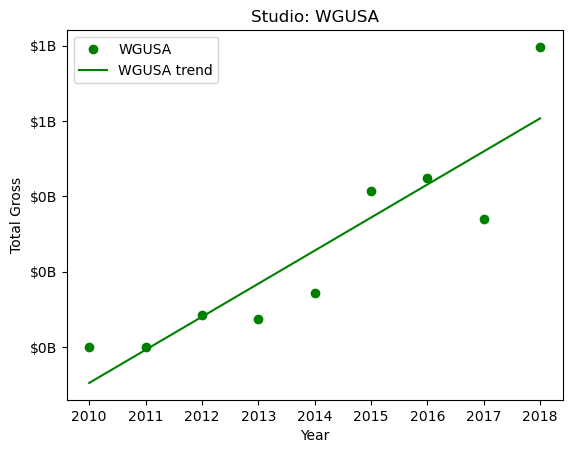


Studio: WGUSA
 -> Slope (gross per year) = 87835288.33
 -> r2 (trend confidence) = 0.8155
 -> p-value (year coefficient) = 0.0008
 -> Trend = upward
 -> Significance = (significant)



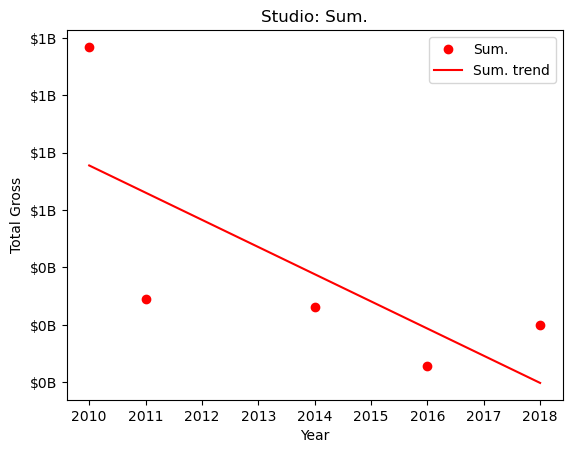


Studio: Sum.
 -> Slope (gross per year) = -94688366.07
 -> r2 (trend confidence) = 0.5154
 -> p-value (year coefficient) = 0.1720
 -> Trend = downward
 -> Significance = (not significant)



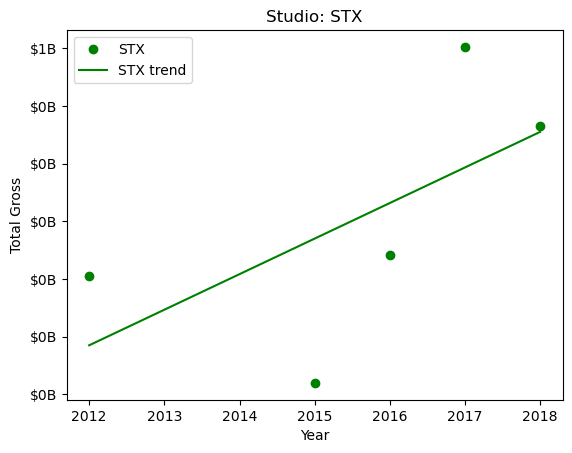


Studio: STX
 -> Slope (gross per year) = 61674528.30
 -> r2 (trend confidence) = 0.3848
 -> p-value (year coefficient) = 0.2642
 -> Trend = upward
 -> Significance = (not significant)



In [639]:
billions = FuncFormatter(lambda x, pos: f"${x/1e9:.0f}B")

for studio_name in top_studios:
    sd = studio_year[studio_year['studio'] == studio_name]
    X = sm.add_constant(sd['year'])
    y = sd['total_gross']
    model = sm.OLS(y, X).fit()
    
    #values
    slope = model.params['year']
    r2 = model.rsquared
    p_val = model.pvalues['year']
    direction = "upward" if slope > 0 else "downward"
    significance = "significant" if p_val < 0.05 else "not significant"

    # plot only for strong trends
    if r2 > 0.3:    
        plt.plot(sd['year'], sd['total_gross'], 'o', color='green'if slope> 0 else "red", label=studio_name)
        plt.plot(sd['year'], model.predict(X), color='green'if slope> 0 else "red", label=f"{studio_name} trend")
        plt.title(f"Studio: {studio_name}")
        plt.xlabel('Year')
        plt.gca().yaxis.set_major_formatter(billions)
        plt.ylabel('Total Gross')
        plt.legend()
        plt.show()
        print(f"\nStudio: {studio_name}")
        print(f" -> Slope (gross per year) = {slope:.2f}")
        print(f" -> r2 (trend confidence) = {r2:.4f}")
        print(f" -> p-value (year coefficient) = {p_val:.4f}")
        print(f" -> Trend = {direction}") 
        print(f" -> Significance = ({significance})\n")


- R² - trend confidence - high for a competitor means they’ve built a reliably growth engine. 

- **High R²** & Low **p-value** - studios revenue trend isn’t just truly going up, it’s doing so consistently and predictably.

From the above info we can conclude that:

- **WB** and **WGSUA** has consistently high been having a growth trajectory - this should advice the marketing/branding teams to study their promotion strategy and see if they can replicate it even if on a smaller scale.
